# Mem-CVM data analyzer. 

In [76]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
from matplotlib.ticker import AutoMinorLocator, NullFormatter

import matplotlib.cm as cm
import os

from src.file_path import list_files_in_folder, filter_cvm_files, find_seq_file
from src.metadata_utils import extract_CVM_dataframe, extract_read_CVM_dataframes, sort_memcvm_dfs
from src.metadata_utils import build_wide_dataframe_from_list, seq_file_parsing, write_csv_with_metadata
from src.metadata_utils import Average_DF, write_csv_with_metadata_with_Vr
from src.utils_stats import ensure_ndarrays, round_vwrite_to_step, select_indices_from_vwrite_direction, group_by_rounded_voltage, build_common_hist_bins
from src.plot import plot_memCVM_overview, plot_memCVM_Vwrite, plot_memCVM_vs_pulse_number, Dashboard_memCVM
from src.plot_stat import plot_mean_vwrite, plot_mean_index
from src.plot_stat import plot_hist_analysis, plot_k


# ──────────────────────────────────────────────────────────────────────────────
#   This code is used to plot the data from the FE tester for the CV                       
# ──────────────────────────────────────────────────────────────────────────────


%config InlineBackend.figure_format = 'retina' # For high resolution figures in Jupyter Notebook
#%matplotlib widget

#### Parameters Configuration

Please configure the following parameters in the cell below:

- **<span style="color:green;">Measurement folder path</span>**  
  ⚠️ Do **not** move any files from this folder, especially the sequence file, as the script extracts metadata from it.

- **<span style="color:green;">Output path</span>**  
  Directory where the generated plots and CSV file will be saved. The script generate two subfolder to store the plot and the csv files.

- **<span style="color:green;">Reading voltage</span>**  

####  Reading Voltage Notice

MEM CVM is a specific type of measurement.  
The **ON/OFF ratio** and **memory window** <span style="color:blue;">depend on the **reading BIAS voltage**</span> . Selecting a voltage that is too high or too low will remove the CVM curve from the dataframe that does not have such voltage.

Plus note the following: The **FE-tester** does not use the same measurement points for each CVM, which can result in different **Vmin** and **Vmax** values for each reading pulse.


In [77]:
# ──────────────────────────────────────────────────────────────────────────────
#   Path                       
# ──────────────────────────────────────────────────────────────────────────────

folder_path = r"C:\Users\natha\Documents\Polybox back up 2026-03-28\01 - Top electrode engineering\02 - Data\02 - FE tester\NASA-002-01\memCVM\2026-02-04_NASA-002-01_ID21-00"
output_path = r"C:\Users\natha\Documents\Polybox back up 2026-03-28\01 - Top electrode engineering\02 - Data\02 - FE tester\NASA-002-01\memCVM\2026-02-03_NASA-002-01_ID21-00"

output_path_csv = os.path.join(output_path, "csv")
output_path_plot = os.path.join(output_path, "plot")



#### Data extraction

In [78]:
# ──────────────────────────────────────────────────────────────────────────────
#   Extraction of dataframes from the source folder                       
# ──────────────────────────────────────────────────────────────────────────────

CVM_reading_files, CVM_complete_file = filter_cvm_files(list_files_in_folder(folder_path))
Read_CVM_Dataframe: list = []
Vwrite_list: list = []

Main_CVM_Dataframe = extract_CVM_dataframe(CVM_complete_file)
Read_CVM_Dataframe = extract_read_CVM_dataframes(CVM_reading_files)

Read_CVM_Dataframe, Vwrite_list, loop_list = sort_memcvm_dfs(Read_CVM_Dataframe)

In [79]:
Read_CVM_Dataframe[1]

,Bias [V],C [F],tan(delta) [1],d33 [nm/V],phi33 [deg],reserved [A],reserved [nm],|Aux| [1],phase(Aux) [],AuxBias [1],Unnamed: 10,Loop,Writing_Voltage_V
0,0.076854,3.283292e-10,0.074808,0.0,0.0,1.320779e-07,0.0,0.000224,221.725600,0.003549,NaN,1,0.666
1,0.193085,3.324268e-10,0.076128,0.0,0.0,1.298598e-07,0.0,0.000058,187.073600,0.003505,NaN,1,0.666
2,0.313522,3.375321e-10,0.080211,0.0,0.0,1.320424e-07,0.0,0.000045,267.208900,0.003746,NaN,1,0.666
3,0.434513,3.427301e-10,0.082409,0.0,0.0,1.317770e-07,0.0,0.000243,126.322200,0.003752,NaN,1,0.666
4,0.557941,3.477075e-10,0.084229,0.0,0.0,1.344869e-07,0.0,0.000044,125.176800,0.003822,NaN,1,0.666
5,0.680271,3.541750e-10,0.086901,0.0,0.0,1.342054e-07,0.0,0.000057,-7.469442,0.003455,NaN,1,0.666
6,0.556671,3.468738e-10,0.081288,0.0,0.0,1.309135e-07,0.0,0.000139,111.058500,0.003643,NaN,1,0.666
7,0.435168,3.427438e-10,0.081383,0.0,0.0,1.300429e-07,0.0,0.000278,108.100400,0.003555,NaN,1,0.666
8,0.314131,3.388371e-10,0.080108,0.0,0.0,1.292098e-07,0.0,0.000103,114.445000,0.003334,NaN,1,0.666
9,0.192712,3.351473e-10,0.078467,0.0,0.0,1.326305e-07,0.0,0.000240,50.170070,0.003521,NaN,1,0.666


#### Dashboard

ON/OFF ratio computed for the last cycle
Dashboard saved to: C:\Users\natha\Documents\Polybox back up 2026-03-28\01 - Top electrode engineering\02 - Data\02 - FE tester\NASA-002-01\memCVM\2026-02-03_NASA-002-01_ID21-00\plot\2026-02-04_NASA-002-01_ID21-00_Dashboard.png


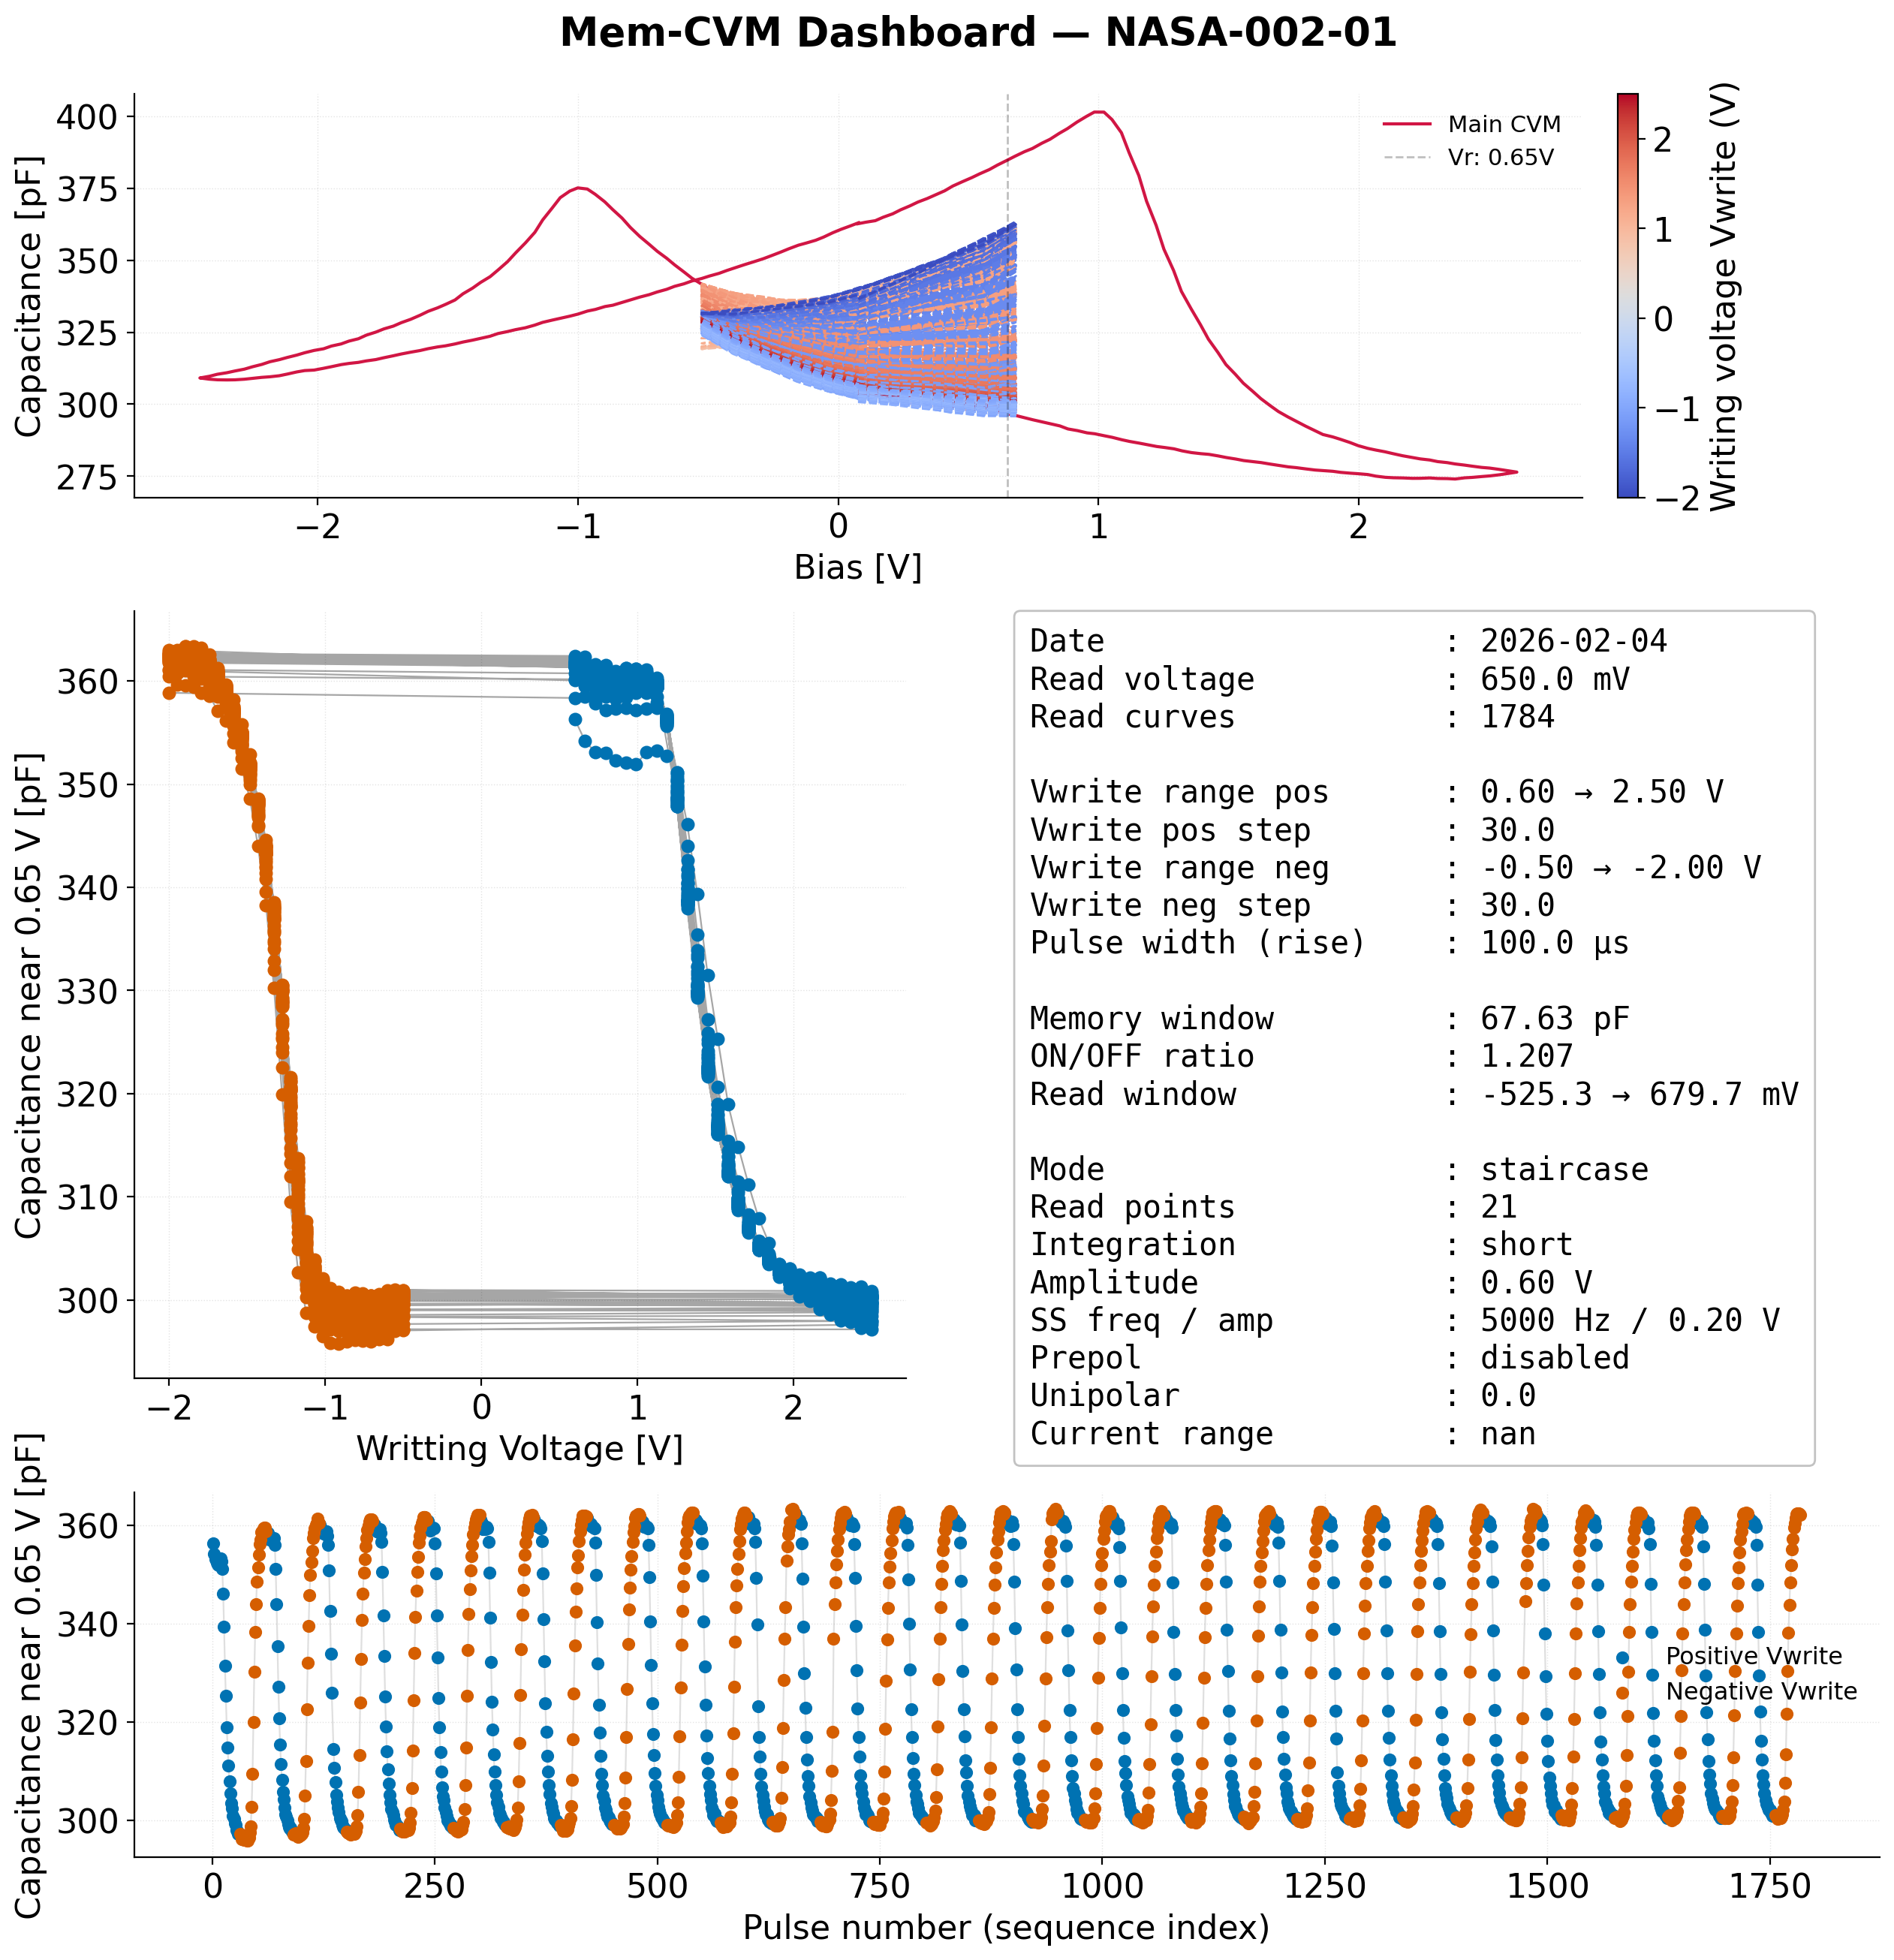

In [80]:
# ──────────────────────────────────────────────────────────────────────────────
#   Plot of the dashboard                       
# ──────────────────────────────────────────────────────────────────────────────

READING_VOLTAGE = 0.65     # In V, The value must be £inside the window of the Bias reading voltage otherwise you'll get an error !

DF_AT_VR = Dashboard_memCVM(Main_CVM_Dataframe=Main_CVM_Dataframe, Read_CVM_Dataframe=Read_CVM_Dataframe, Vwrite_list=Vwrite_list, reading_voltage=READING_VOLTAGE, path_metadata=folder_path, Output_path=output_path_plot)
DF_MEAN = Average_DF(df = DF_AT_VR)

# ──────────────────────────────────────────────────────────────────────────────
#                           Export csv
# ──────────────────────────────────────────────────────────────────────────────

metadata_df = seq_file_parsing(folder_path)
read_df_wide = build_wide_dataframe_from_list(
    Read_CVM_Dataframe,
    Vwrite_list=Vwrite_list,
    v_col="Bias [V]",
    c_col="C [F]"
)

write_csv_with_metadata(Output_path=output_path_csv, df_metadata=metadata_df, df_data=read_df_wide)
write_csv_with_metadata_with_Vr(Output_path=output_path_csv, df_metadata=metadata_df, df_data=DF_AT_VR, READING_VOLTAGE=READING_VOLTAGE)

#### Single plot

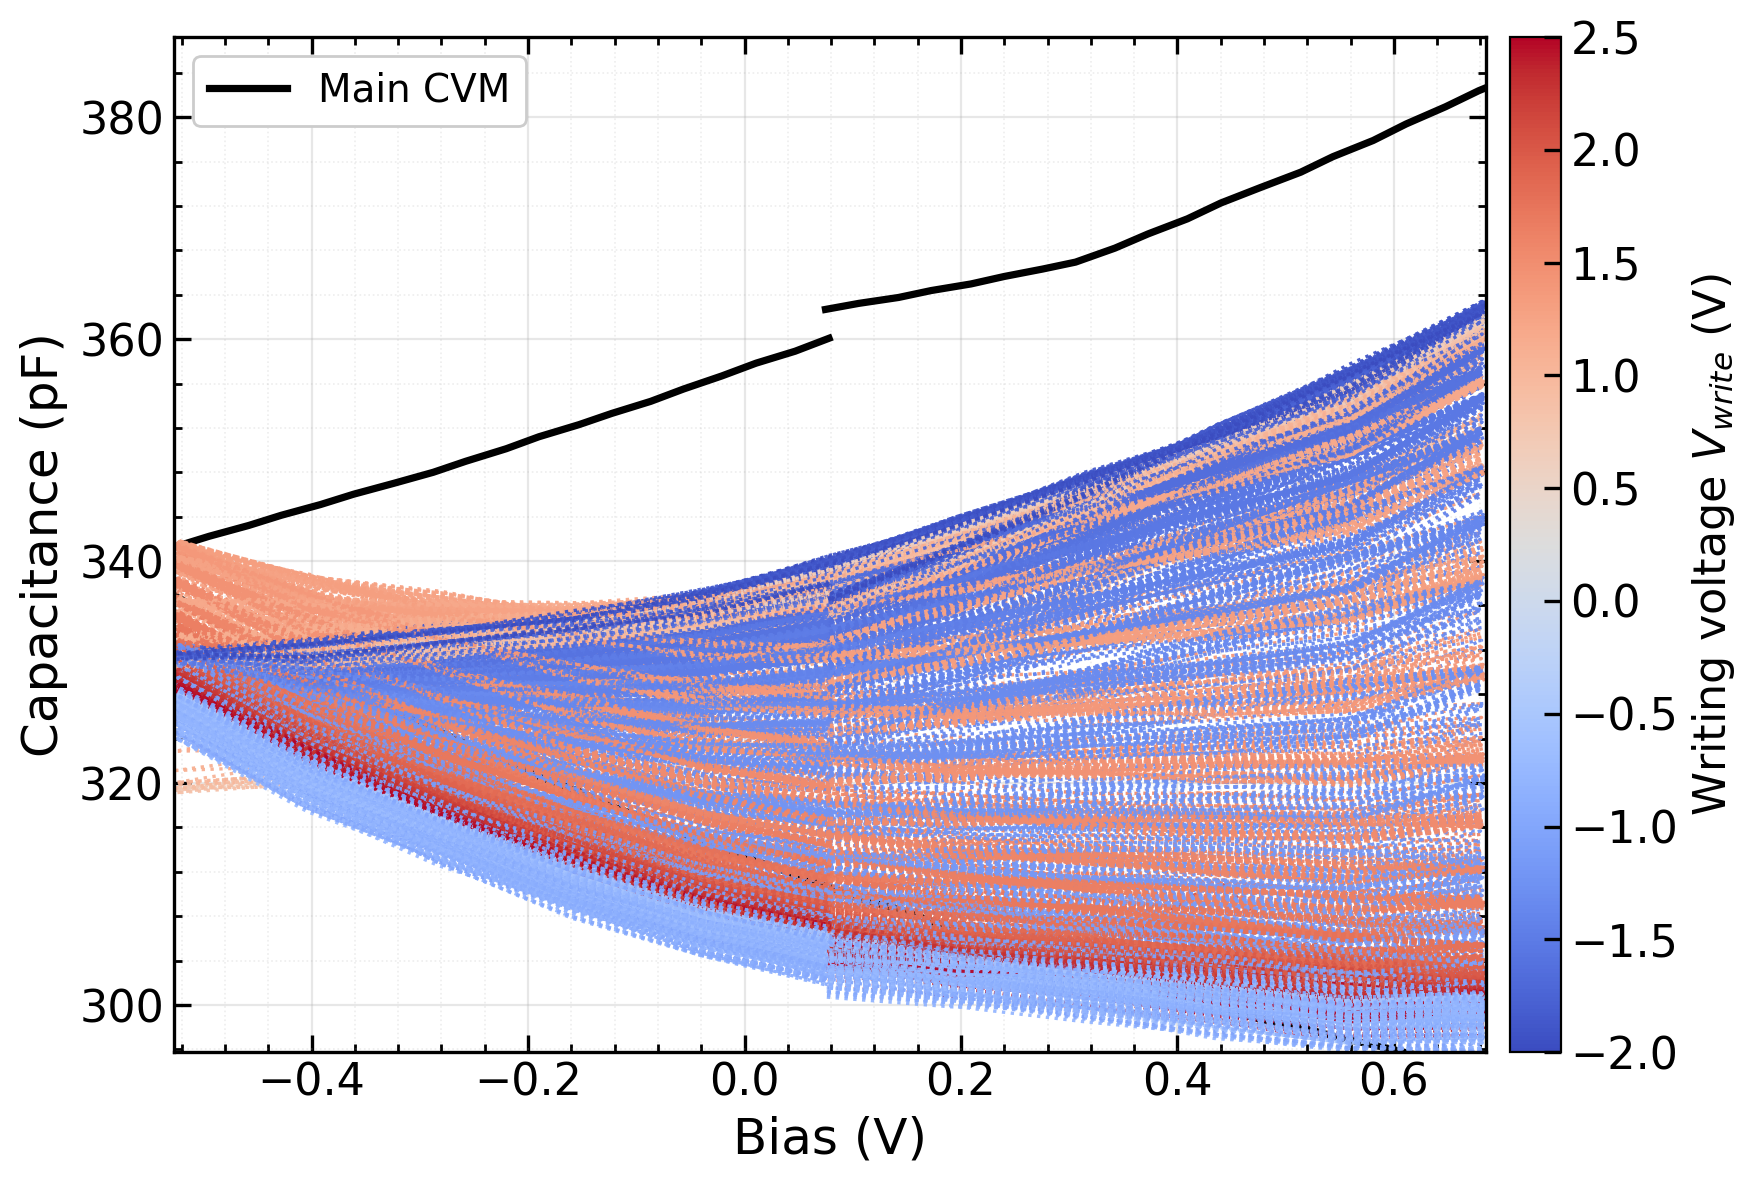

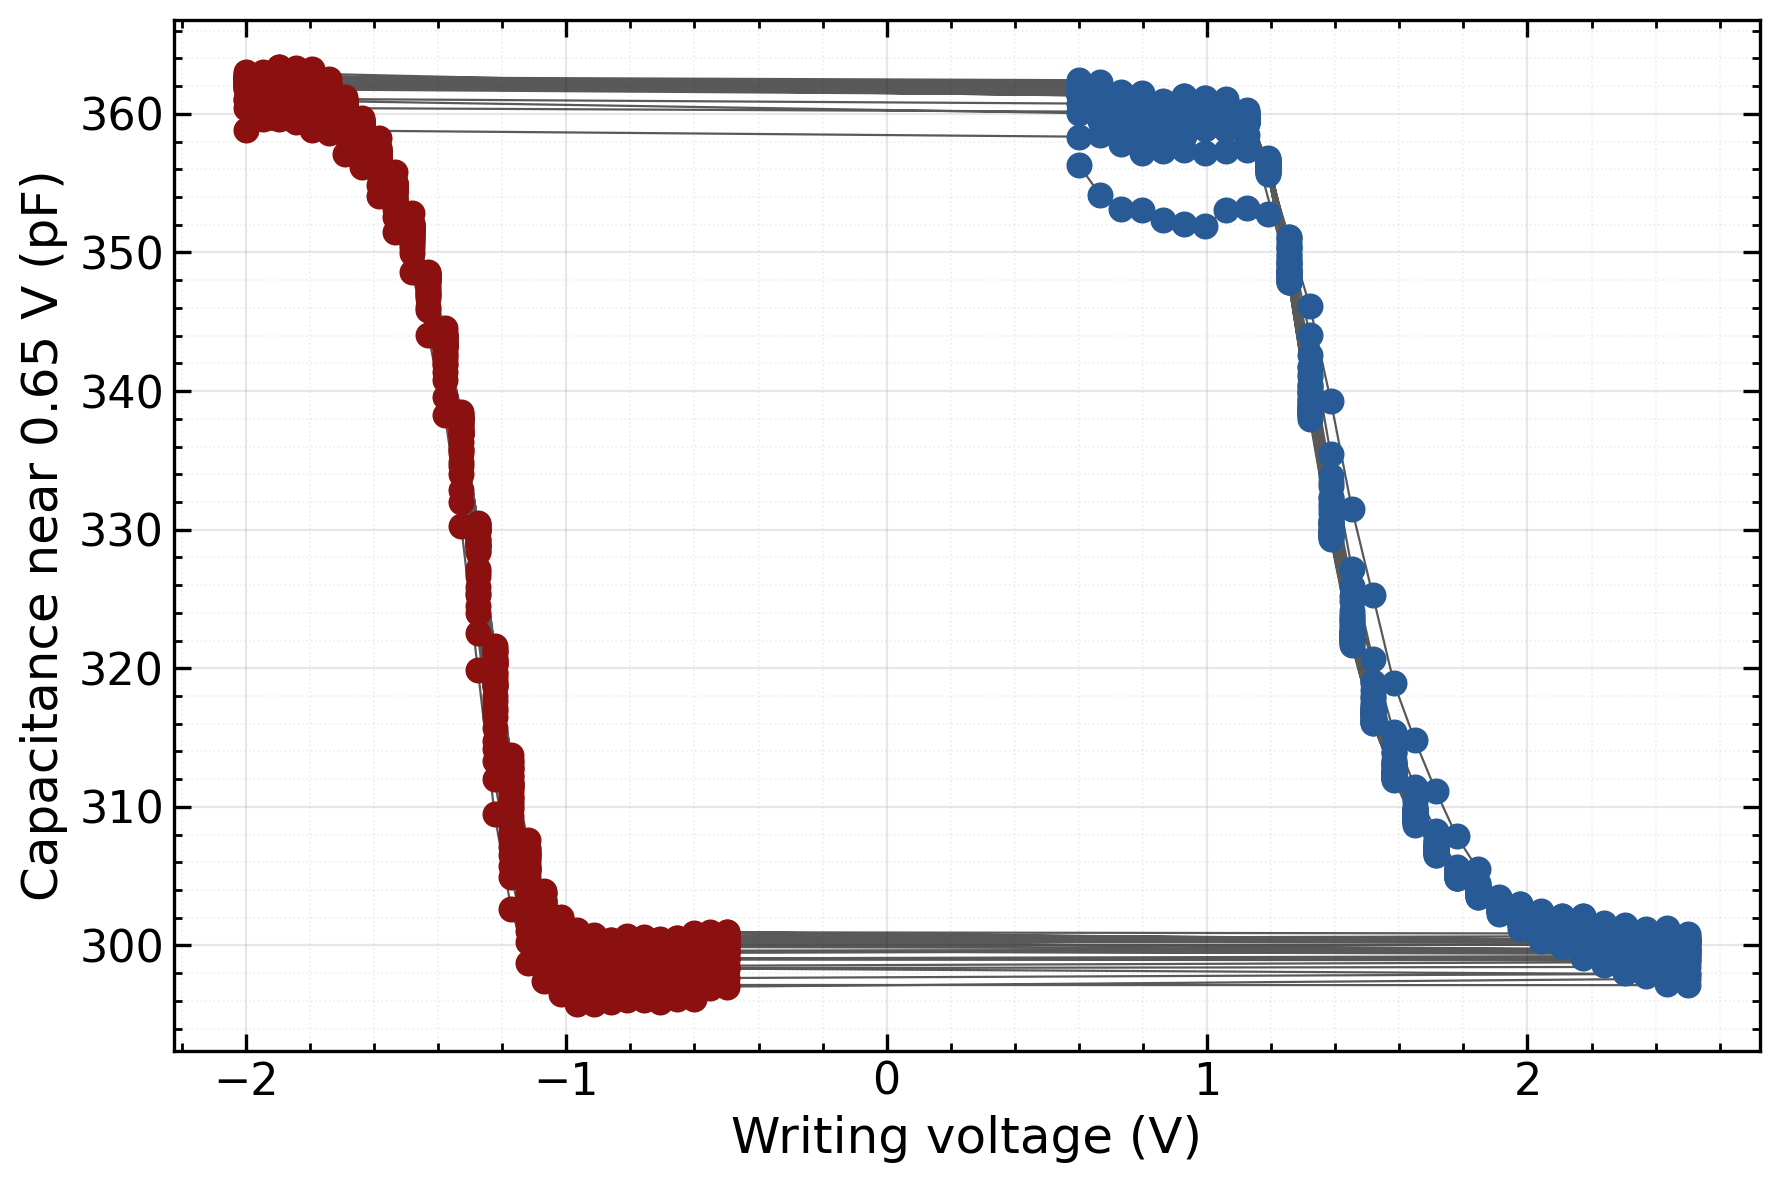

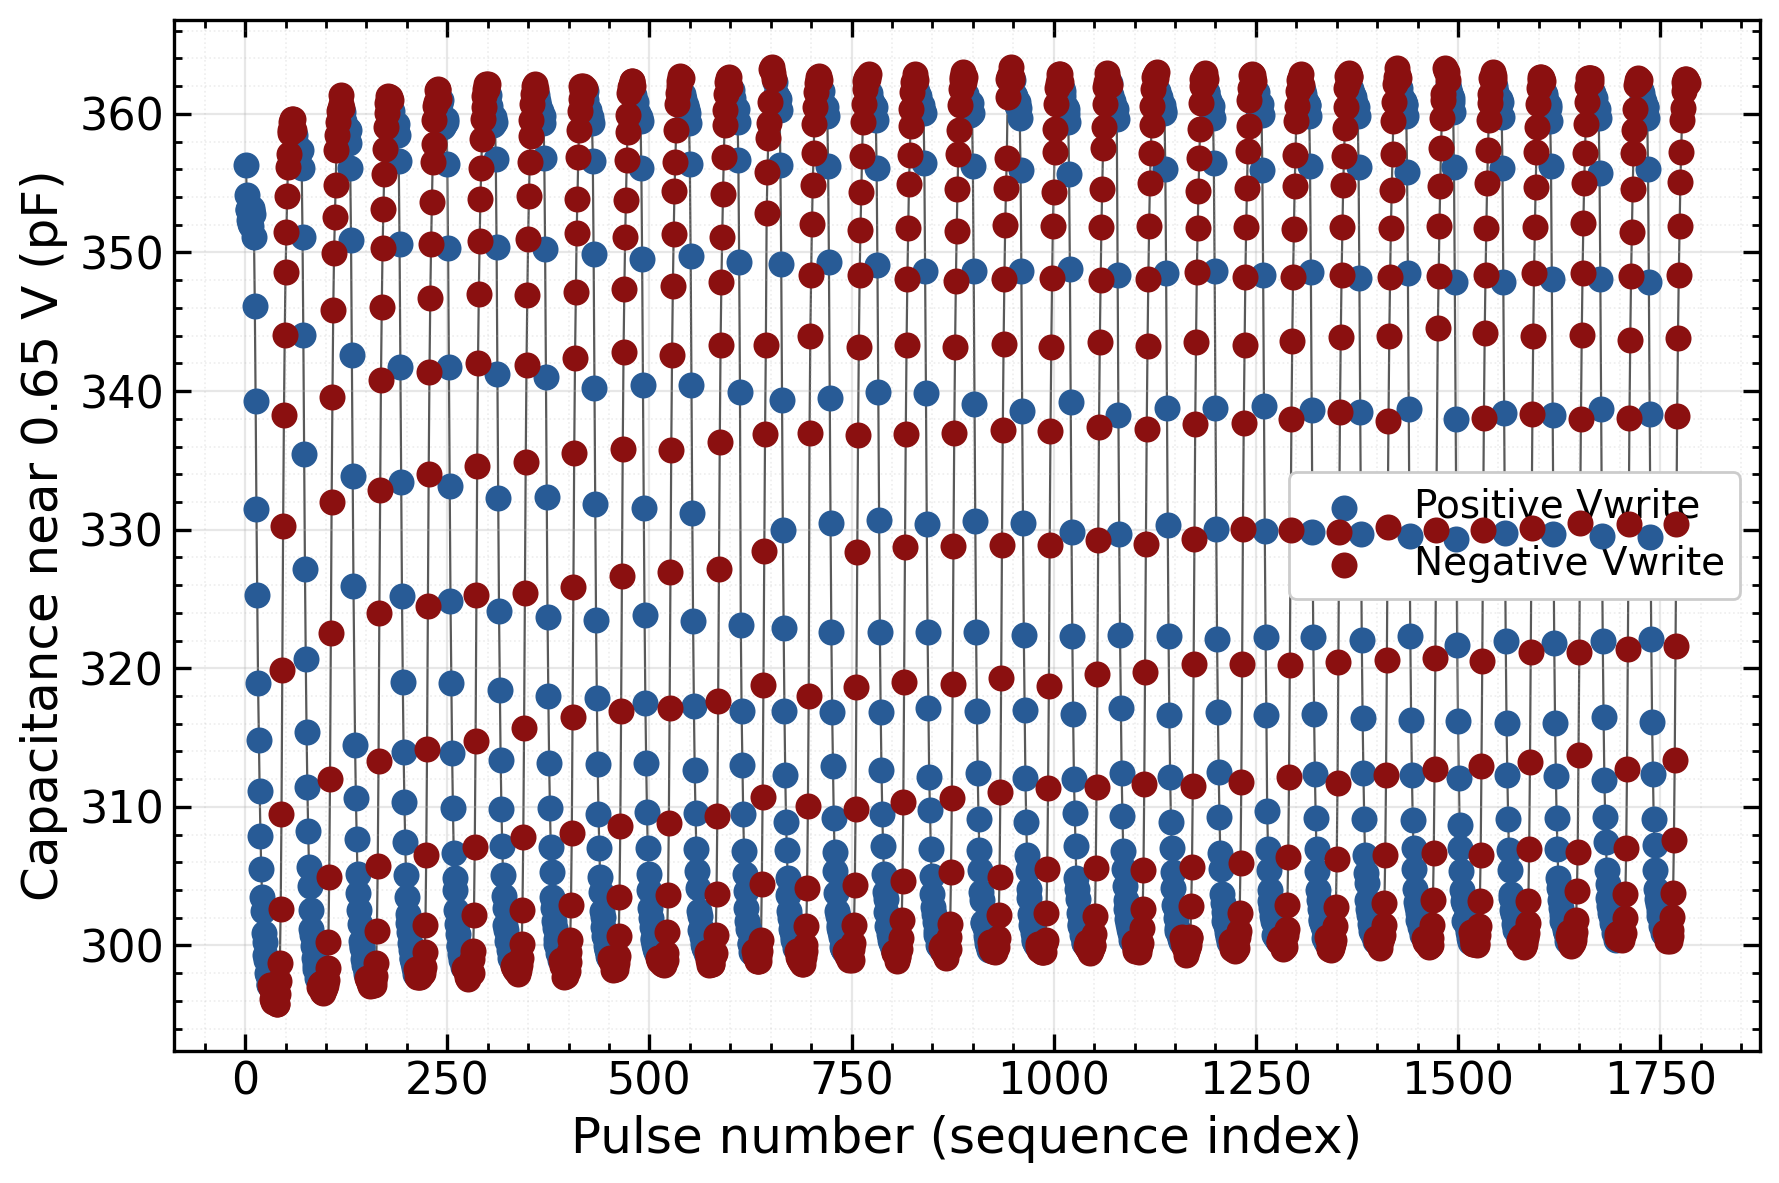

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Pulse number (sequence index)', ylabel='Capacitance near 0.65 V (pF)'>,
 'C:\\Users\\natha\\Documents\\Polybox back up 2026-03-28\\01 - Top electrode engineering\\02 - Data\\02 - FE tester\\NASA-002-01\\memCVM\\2026-02-03_NASA-002-01_ID21-00\\plot\\2026-02-04_NASA-002-01_ID21-00_Cmem_vs_pulse.png')

In [81]:
# ──────────────────────────────────────────────────────────────────────────────
#                           Plot
# ──────────────────────────────────────────────────────────────────────────────

# Vue d'ensemble des mesures mémoire CVM
plot_memCVM_overview(
    Main_CVM_Dataframe=Main_CVM_Dataframe,
    Read_CVM_Dataframe=Read_CVM_Dataframe,
    path_metadata=folder_path,
    Output_dir=output_path_plot,
    reading_voltage=READING_VOLTAGE,
    Vwrite_list=Vwrite_list
)

# Capacité vs tension d'écriture (à tension de lecture fixe)
plot_memCVM_Vwrite(
    Read_CVM_Dataframe=Read_CVM_Dataframe,
    path_metadata=folder_path,
    Output_dir=output_path_plot,
    marker_size=70,
    reading_voltage=READING_VOLTAGE
)

# Évolution de la capacité en fonction du numéro d'impulsion
plot_memCVM_vs_pulse_number(
    Read_CVM_Dataframe=Read_CVM_Dataframe,
    path_metadata=folder_path,
    Output_dir=output_path_plot,
    marker_size=70,
    Vwrite_list=Vwrite_list,
    reading_voltage=READING_VOLTAGE
)

# Average plot

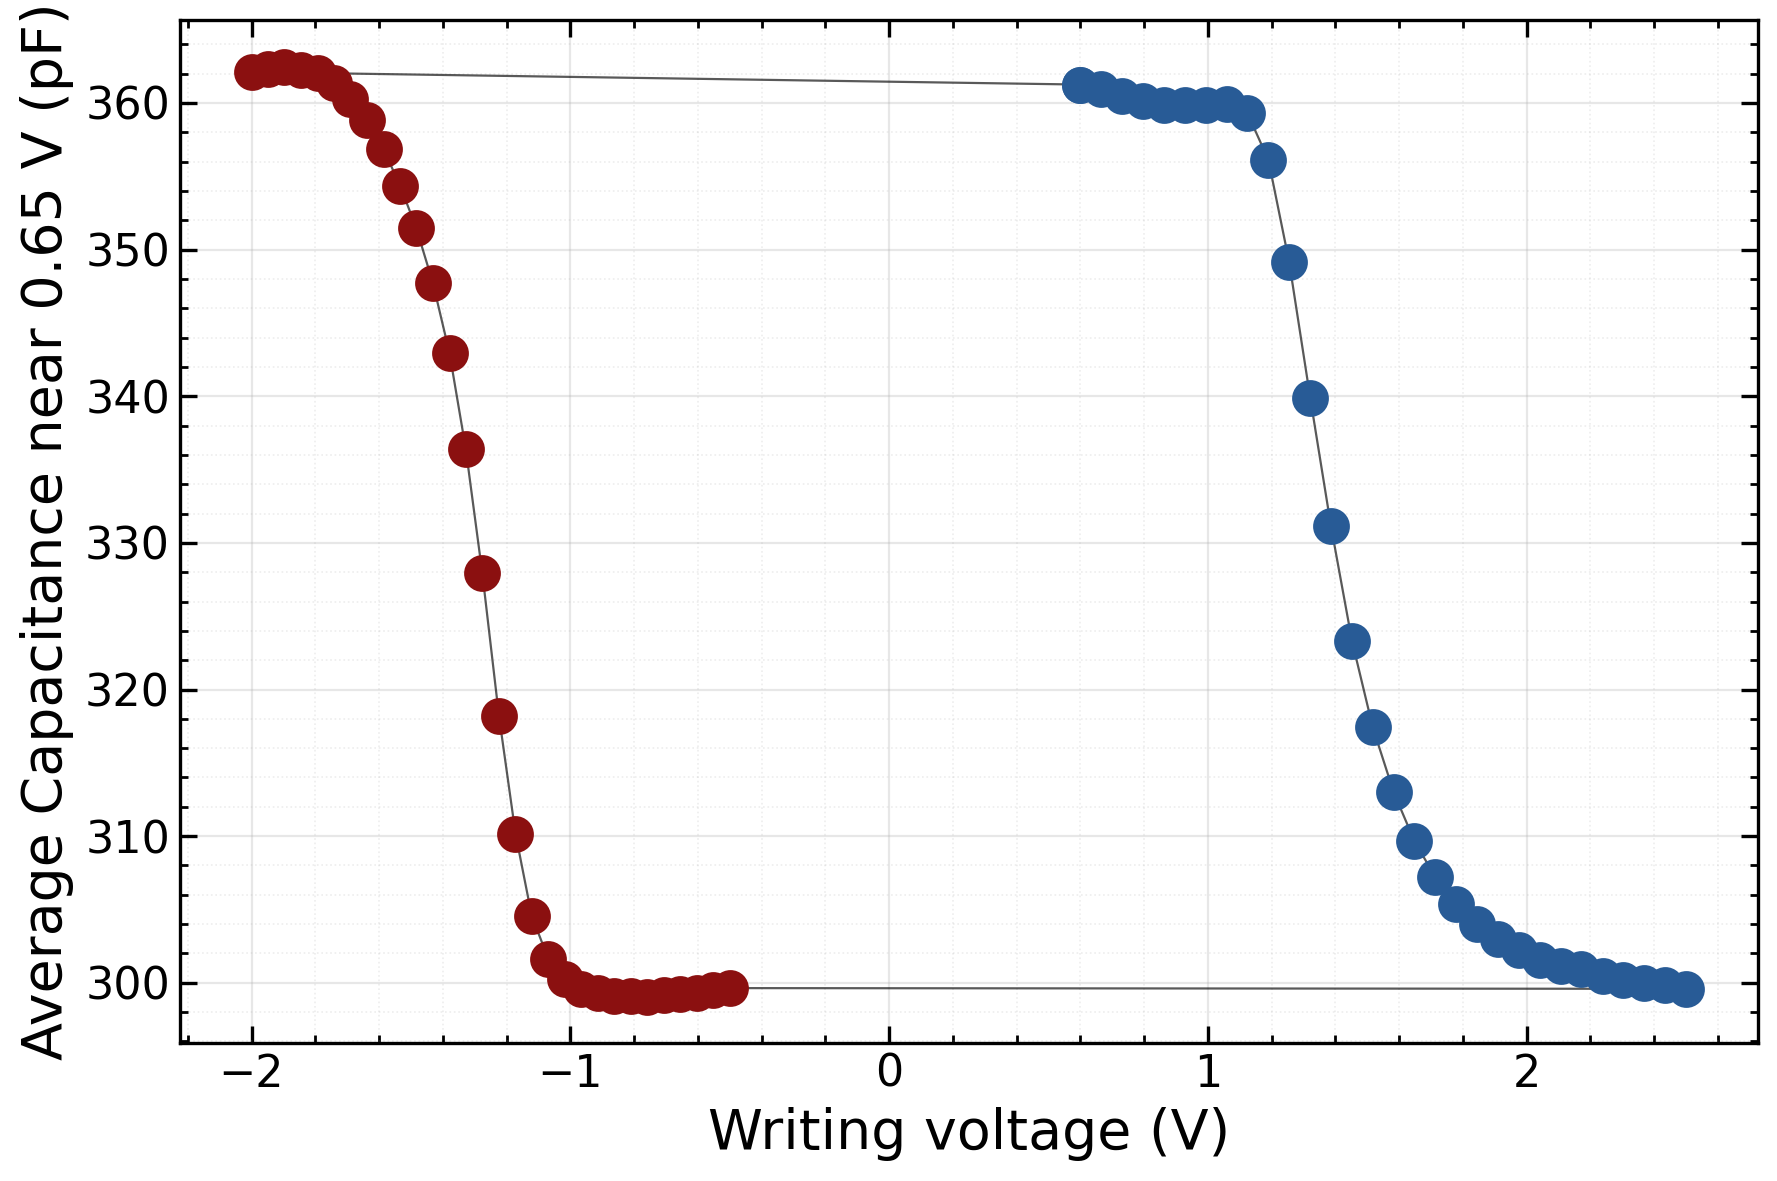

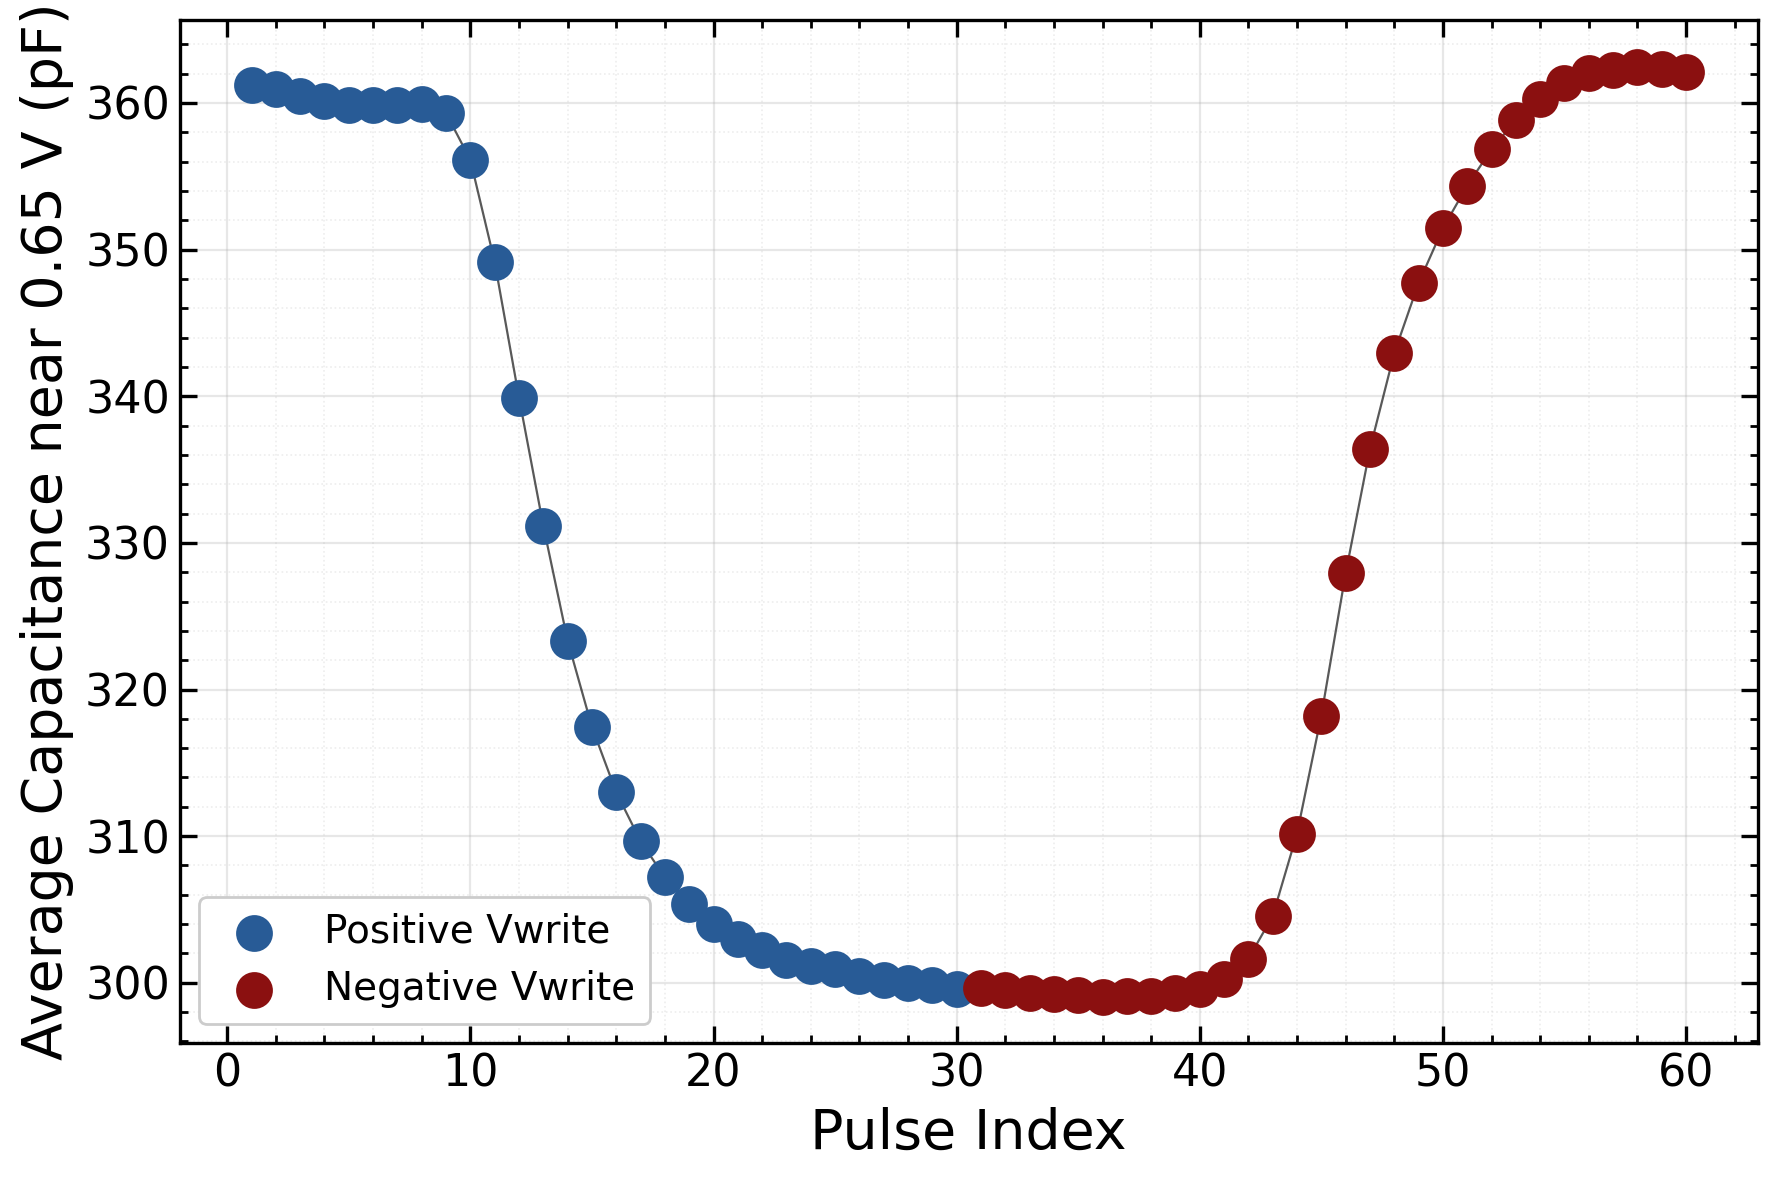

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Pulse Index', ylabel='Average Capacitance near 0.65 V (pF)'>,
 'C:\\Users\\natha\\Documents\\Polybox back up 2026-03-28\\01 - Top electrode engineering\\02 - Data\\02 - FE tester\\NASA-002-01\\memCVM\\2026-02-03_NASA-002-01_ID21-00\\plot\\2026-02-04_NASA-002-01_ID21-00_AVERAGE_Cmem_vs_Index.png')

In [82]:
# ──────────────────────────────────────────────────────────────────────────────
#   Plot of Average plot                       
# ──────────────────────────────────────────────────────────────────────────────

plot_mean_vwrite(DF_MEAN=DF_MEAN, marker_size = 150, Label_size=20, metadata=metadata_df, Output_dir=output_path_plot, reading_voltage=READING_VOLTAGE)
plot_mean_index(DF_MEAN=DF_MEAN, marker_size = 150,  Label_size=20, metadata=metadata_df, Output_dir=output_path_plot, reading_voltage=READING_VOLTAGE)


# Statistical analysis

#### WARNING
The value you choose for "round_by" is critical, you'll have very different results depending on the rounding value for the number of distinct state.

As a rule of thumbs I usually choose 50 mV because it's often a value that is close to my writting voltage step size.

In [83]:
# ──────────────────────────────────────────────────────────────────────────────
#                           Input parameters for statistical analysis
# ──────────────────────────────────────────────────────────────────────────────

round_by = 0.05
vwrite_threshold_pos = 0.05  # Okay here is a strange cookie, with this variable we eliminate the datapoint that are smaller that this variable...
vwrite_threshold_neg = 0.05  # I think the intention was to remove the non significant point, a bit sketchy maboi
nbr_bins = 100              # A bin is a group when we use histogram. how many bin in your histogram


#### Data processing
Here are built the histogram used for the gaussian fit and the count of the number of distinct state.

In [84]:
# ──────────────────────────────────────────────────────────────────────────────
#                           Data processing
# ──────────────────────────────────────────────────────────────────────────────

Index = DF_AT_VR["Index"]
V_write = DF_AT_VR["Vwrite"]
C = DF_AT_VR["Cmem"]


V_write, C = ensure_ndarrays(V_write=V_write, C_array=C)    # So we work with array python object
C=C*1e+12
C_min = np.min(C)
C_max = np.max(C)
W = (C-C_min)/(C_max-C_min)
Vw_round = round_vwrite_to_step(Vw=V_write, round_by=round_by)

selected_idx = select_indices_from_vwrite_direction(V_write, Vw_round, vwrite_threshold_pos, vwrite_threshold_neg )

C_sorted = group_by_rounded_voltage(Vw_round=Vw_round, Y=C, selected_idx=selected_idx)
W_sorted = group_by_rounded_voltage(Vw_round=Vw_round, Y=W, selected_idx=selected_idx)

bins_C = build_common_hist_bins(C_grouped_by_V=C_sorted, n_bins=nbr_bins)
bins_W = build_common_hist_bins(C_grouped_by_V=W_sorted, n_bins=nbr_bins)

Ns = [len(arr) for arr in C_sorted.values()]
print("N per state: min =", min(Ns), "median =", np.median(Ns), "max =", max(Ns))

Here is the list of the rounded voltage use for the analysis :[-2.   -1.95 -1.9  -1.85 -1.8  -1.75 -1.7  -1.65 -1.6  -1.55 -1.5  -1.45
 -1.4  -1.35 -1.3  -1.2  -1.15 -1.1  -1.05 -1.   -0.95 -0.9  -0.85 -0.8
 -0.75 -0.7  -0.65 -0.6  -0.55 -0.5   0.6   0.65  0.75  0.8   0.85  0.95
  1.    1.05  1.1   1.2   1.25  1.3   1.4   1.45  1.5   1.6   1.65  1.7
  1.8   1.85  1.9   2.    2.05  2.1   2.15  2.25  2.3   2.35  2.45  2.5 ]
N per state: min = 28 median = 30.0 max = 30


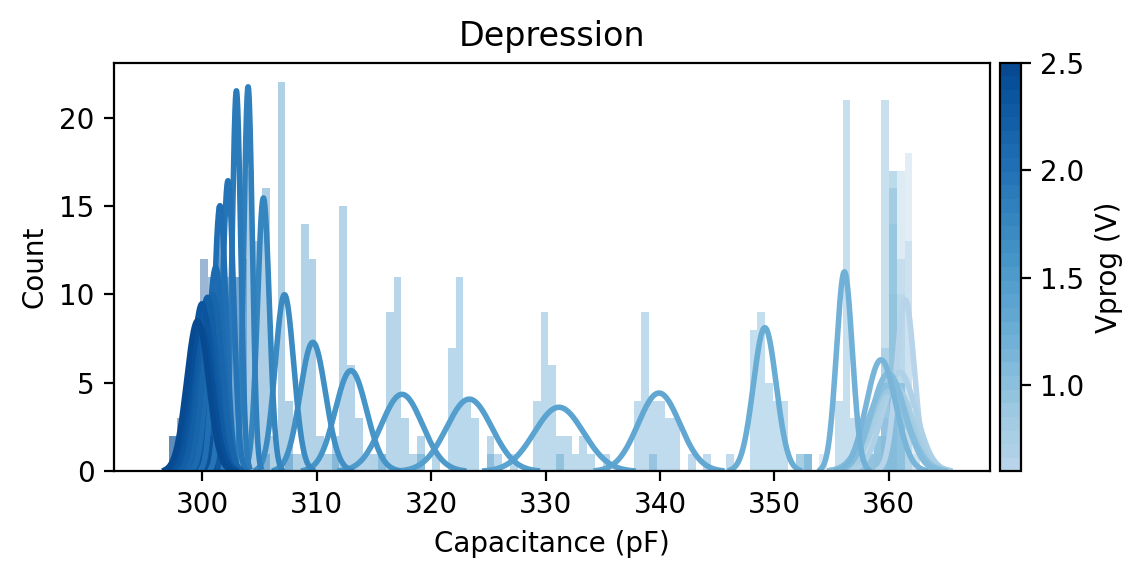

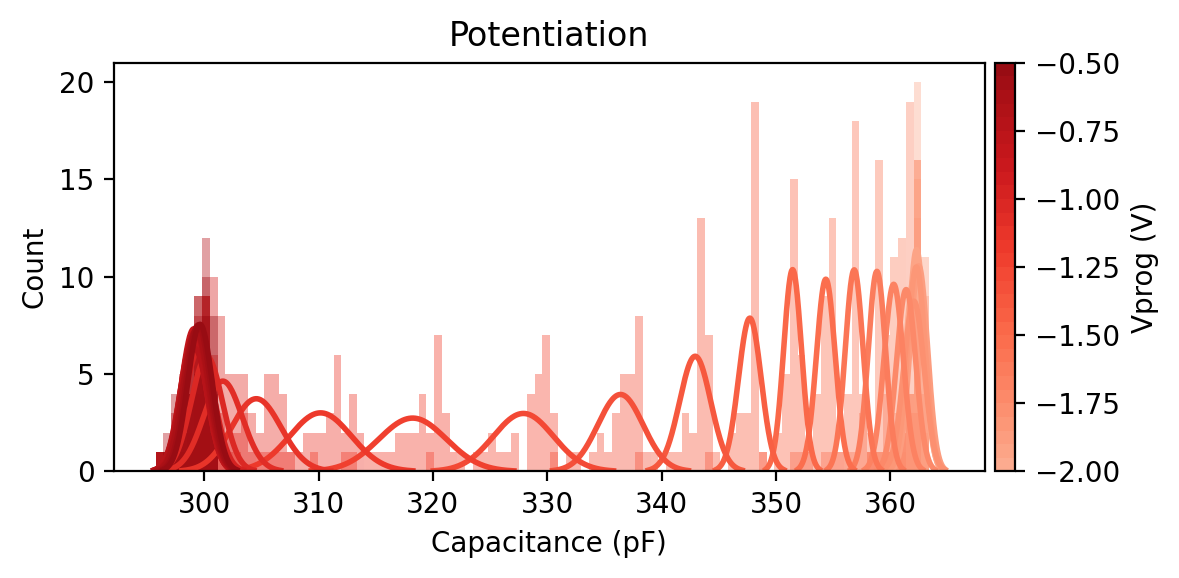

In [85]:
# ──────────────────────────────────────────────────────────────────────────────
#                           Statistical plots
# ──────────────────────────────────────────────────────────────────────────────

statistics_df_C_LTD, statistics_df_C_LTP = plot_hist_analysis(
    C_sorted=C_sorted,
    bins=bins_C,
    round_by=round_by,
    vwrite_threshold_pos=vwrite_threshold_pos,
    vwrite_threshold_neg=vwrite_threshold_neg,
    Label="Capacitance (pF)",
    figsize=(9,6)
)

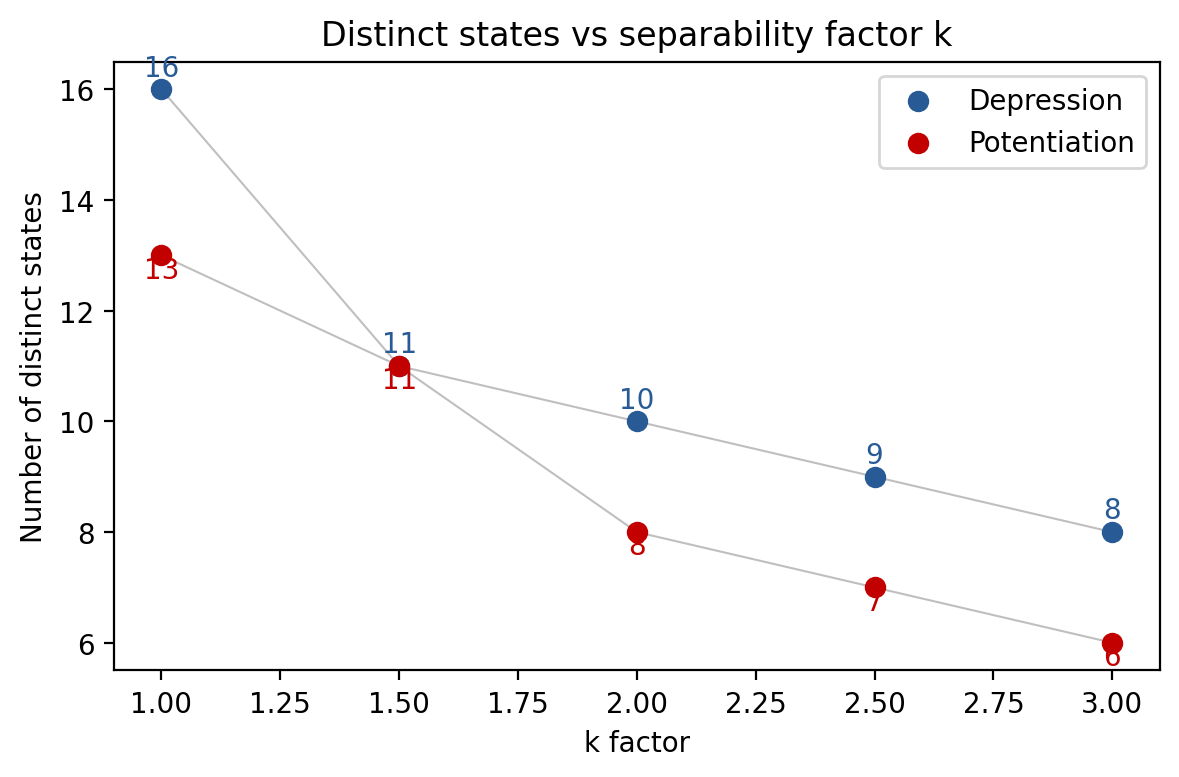

In [86]:
# ──────────────────────────────────────────────────────────────────────────────
#                           K-factor plot  
# ──────────────────────────────────────────────────────────────────────────────

plot_k(statistics_df_LTD=statistics_df_C_LTD, statistics_df_LTP=statistics_df_C_LTP)


0.5860450009593724
N_states_median: 7.919266297961823
N_states_worst: 3.5535688619322623


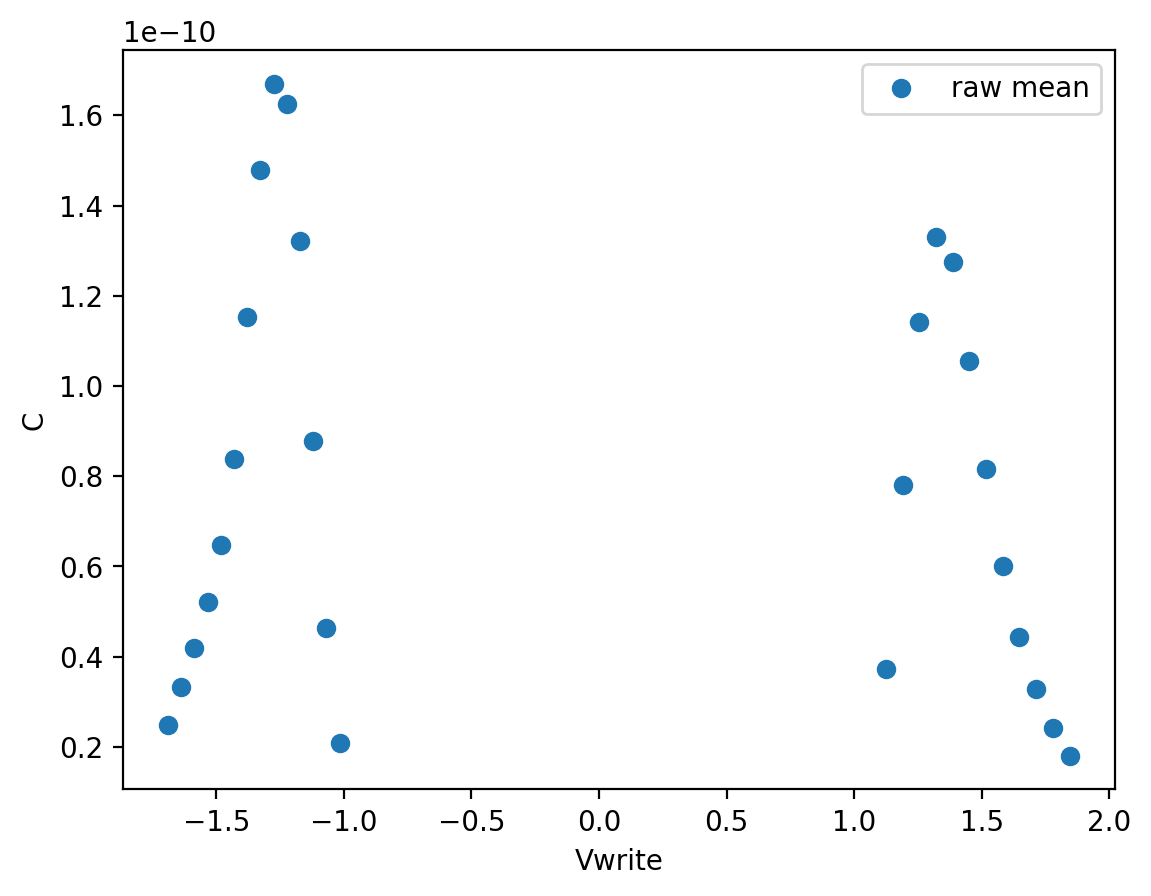

In [87]:

C_mean = DF_MEAN["Cmem"].to_numpy()
V = DF_MEAN["Vwrite"].to_numpy()

delta_C = np.percentile(C_mean, 95) - np.percentile(C_mean, 5)


from scipy.signal import savgol_filter

"""
Rule of thumb:
window ≈ 5–15% of the total number of V points
must be odd
"""
C_smooth = savgol_filter(
    C_mean,
    window_length=7,  # odd, tune if needed
    polyorder=3
)


dCdV = np.gradient(C_smooth, V)
abs_slope = np.abs(dCdV)

alpha = 0.1
mask_active = abs_slope >= alpha * abs_slope.max()

slope_uniformity = abs_slope[mask_active].std() / abs_slope[mask_active].mean()

slope_uniformity = abs_slope[mask_active].std() / abs_slope[mask_active].mean()
print(slope_uniformity)


sigma_C = DF_MEAN["C_std"].to_numpy()
sigma_active = sigma_C[mask_active]

k = 6  # conservative

sigma_med = np.median(sigma_active)
sigma_worst = np.max(sigma_active)

N_states_median = delta_C / (k * sigma_med)
N_states_worst  = delta_C / (k * sigma_worst)
print(f"N_states_median: {N_states_median}")
print(f"N_states_worst: {N_states_worst}")


plt.plot(V[mask_active], abs_slope[mask_active], "o", label="raw mean")
plt.legend()
plt.xlabel("Vwrite")
plt.ylabel("C")
plt.show()


## 🚀 Ideas & Improvements to Explore

#### 🧩 Code Robustness (plot.py)

Add an if condition in plot.py to handle cases where the reading CVM uses a triangular waveform.
Currently, only the staircase waveform is implemented in the script.

#### 📊 Introduce a new plot series showing how:

- the memory window, and
- the ON–OFF ratio
- evolve as a function of the available reading-voltage range.

#### 🔍 Reading-Induced Domain Switching Check

Add a dedicated plot series to detect whether the reading operation itself switches the domain.
Proposed approach:
- Track the minimum voltage of the reading CVM.
- Since the signal ramps up and down, it crosses the same voltage twice.
- Compare the capacitance values at these crossings to detect any discrepancy that could indicate switching.

#### ⚠️ Data Validation & Timeout Handling

Add a verification step and a status string indicating the number of timeouts during the reading CVM.
Rationale:

- Occasionally, a reading pulse fails and produces invalid data that should be ignored.
- Some handling already exists in get_capacitance_from_target (metadata_utils.py):
- If the target voltage is missing from the reading pulse dataframe, the result is set to NaN.

Proposed improvement:
- Use the expected number of datapoints (known from the .seq file metadata).
- Verify this against the dataframe.
- Automatically discard reading pulses that do not meet the expected datapoint count.